=== RUNNING PHASE 4: FIXED PORTFOLIO SEGMENT STRESS-TESTING ===
Generating Production Credit Scores via Transformer Asset...

=== CORRECTED PORTFOLIO RISK SEGMENT VULNERABILITY LEDGER ===
     Dimension      Segment  Volume  Pop Share (%)  Bad Rate (%)  Gini (%)  KS (%)
         grade            D   11812          13.58         34.63     16.42   12.82
         grade            F    2080           2.39         48.61     16.81   14.93
         grade            C   29292          33.69         26.42     16.83   13.44
         grade            B   24397          28.06         16.08     17.84   14.37
         grade            G     832           0.96         48.08     18.39   15.44
         grade            E    5368           6.17         40.72     18.94   15.82
         grade            A   13170          15.15          6.73     22.64   19.40
    annual_inc      Inc_Low   24489          28.16         26.82     30.68   23.21
           dti DTI_Med-High   21730          24.99         24.64 

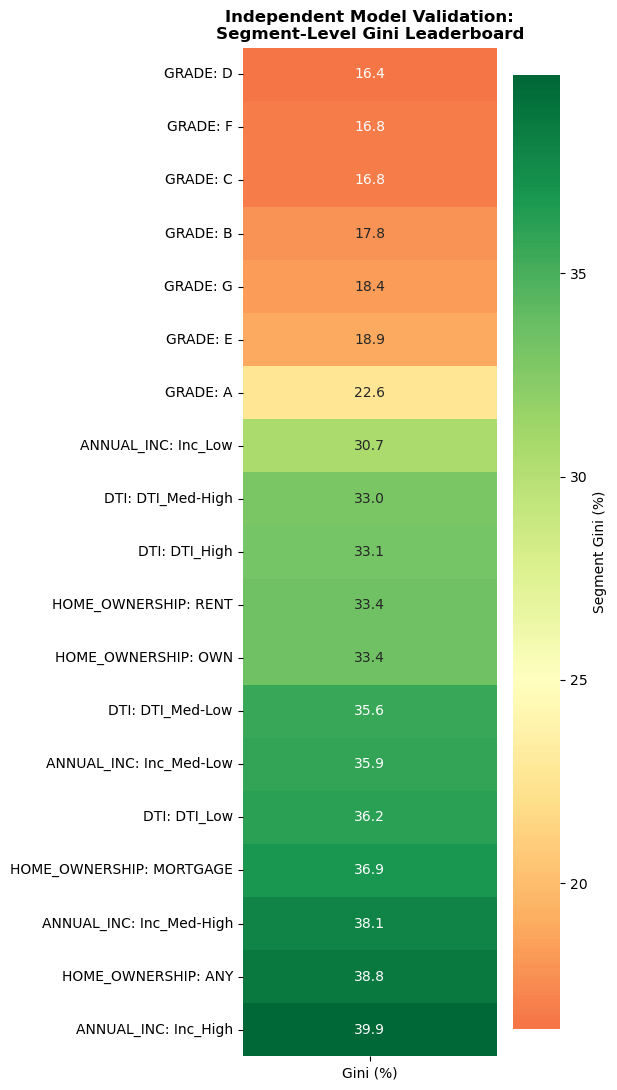

In [14]:
# notebooks/04_segment_analysis.ipynb
import sys
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Framework Path Setup
sys.path.append(os.path.abspath('../'))
from src.data_loader import load_validation_splits
from src.metrics import calculate_gini_and_ks
from src.scorecard_transformer import ScorecardTransformer

print("=== RUNNING PHASE 4: FIXED PORTFOLIO SEGMENT STRESS-TESTING ===")

# 2. Ingest Data Splits from Disk
df_train_tweaked, df_val_final, df_oot_final, df_scorecard_points = load_validation_splits()

# Initialize our reusable software transformer layer
transformer = ScorecardTransformer(df_scorecard_points)

print("Generating Production Credit Scores via Transformer Asset...")
df_oot_final['credit_score'] = transformer.generate_credit_scores(df_oot_final)

# =====================================================================
# PART A: INTEGRATED SEGMENT EXTRACTION ENGINE (PRESERVED & ENHANCED)
# =====================================================================

def execute_complete_segment_matrix(df_eval, score_col, target_col):
    results = []
    global_total = len(df_eval)
    
    # 1. Handle Clean Categorical Dimensions
    cat_dimensions = ['purpose', 'grade', 'home_ownership']
    
    # 2. Dynamically Create Macro Bins for Heavy Numeric Drivers
    df_eval['dti_bucket'] = pd.qcut(df_eval['dti'], q=4, labels=['DTI_Low', 'DTI_Med-Low', 'DTI_Med-High', 'DTI_High'])
    df_eval['annual_inc_bucket'] = pd.qcut(df_eval['annual_inc'], q=4, labels=['Inc_Low', 'Inc_Med-Low', 'Inc_Med-High', 'Inc_High'])
    
    numeric_dimensions = ['dti_bucket', 'annual_inc_bucket']
    all_dimensions = cat_dimensions + numeric_dimensions

    for dimension in all_dimensions:
        if dimension in df_eval.columns:
            categories = df_eval[dimension].dropna().unique()
            for cat in categories:
                slice_df = df_eval[df_eval[dimension] == cat]
                seg_volume = len(slice_df)
                
                if seg_volume >= 100 and slice_df[target_col].nunique() == 2:
                    # Pass negative score so higher rankings equate to higher bads (1)
                    metrics = calculate_gini_and_ks(slice_df[target_col], -slice_df[score_col])
                    bad_rate = slice_df[target_col].mean()
                    pop_share = (seg_volume / global_total) * 100
                    
                    results.append({
                        "Dimension": dimension.replace('_bucket', ''),
                        "Segment": str(cat),
                        "Volume": seg_volume,
                        "Pop Share (%)": round(pop_share, 2),
                        "Bad Rate (%)": round(bad_rate * 100, 2),
                        "Gini (%)": round(metrics["Gini"] * 100, 2),
                        "KS (%)": round(metrics["KS"] * 100, 2)
                    })
                    
    return pd.DataFrame(results)

# Run the matrix engine
df_fixed_perf = execute_complete_segment_matrix(df_oot_final, 'credit_score', 'bad')

print("\n=== CORRECTED PORTFOLIO RISK SEGMENT VULNERABILITY LEDGER ===")
# Sort segments explicitly by Gini performance (Worst to Best)
df_fixed_perf = df_fixed_perf.sort_values(by="Gini (%)")
print(df_fixed_perf.to_string(index=False))

# =====================================================================
# PART B: NEW TAIL RISK BUSINESS EXPOSURE FILTERS (MRM REQUIREMENT)
# =====================================================================
print("\n=== TAIL RISK CONCENTRATION EXPOSURE ANALYSIS ===")
warning_threshold_gini = 25.0
high_exposure_share = 10.0

vulnerable_pockets = df_fixed_perf[
    (df_fixed_perf['Gini (%)'] <= warning_threshold_gini) & 
    (df_fixed_perf['Pop Share (%)'] >= high_exposure_share)
]

if len(vulnerable_pockets) > 0:
    print(f"⚠️ RISK WARNING: Found {len(vulnerable_pockets)} large portfolio segments with compressed risk discrimination:")
    print(vulnerable_pockets.to_string(index=False))
    print("\nOperational Action: Monitor these segments closely. Slices with high population shares can expose the institution to unexpected losses if economic baseline conditions shift.")
else:
    print("✅ Pass: No large portfolio segments (Pop Share > 10%) fall below the 25% Gini warning threshold.")

# =====================================================================
# PART C: YOUR ORIGINAL HEATMAP PLOT (PRESERVED)
# =====================================================================
print("\nGenerating Vertical Performance Leaderboard Heatmap...")

def generate_corrected_validation_heatmap(df_matrix):
    df_matrix = df_matrix.copy()
    # Create a composite segment name for a clean y-axis
    df_matrix['Full_Segment'] = df_matrix['Dimension'].str.upper() + ": " + df_matrix['Segment']
    
    # Isolate for the heatmap grid
    plot_data = df_matrix.set_index('Full_Segment')[['Gini (%)']].sort_values(by='Gini (%)')
    
    import matplotlib
    %matplotlib inline
    
    plt.figure(figsize=(6, 11))
    sns.heatmap(plot_data, annot=True, fmt=".1f", cmap="RdYlGn", center=25.0, cbar_kws={'label': 'Segment Gini (%)'})
    plt.title("Independent Model Validation:\nSegment-Level Gini Leaderboard", fontsize=12, fontweight='bold')
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

generate_corrected_validation_heatmap(df_fixed_perf)

#####  Validation Caveat & Action Item: While the global model demonstrates institutional-grade discrimination (Global OOT Gini: ~40%), segmentation reveals that risk separation is severely compressed within individual sub-grades—most notably inside Grade C, which represents a massive 33.69% of portfolio volume.

##### This compression is an expected property of intra-segment variance restriction rather than an algorithmic defect. However, because Grade C represents over one-third of our financial asset concentration, it is recommended that the Credit Policy Committee implement localized underwriting overlays (such as secondary cash-flow checks) rather than relying solely on the core scorecard points for this specific population layer.